In [1]:
!pip install -q agentmail google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.5/352.5 kB 9.0 MB/s eta 0:00:00


In [3]:
# pulling both api keys

from google.colab import userdata

agentmail_key = userdata.get('AGENTMAIL_API_KEY')
gemini_key = userdata.get('GEMINI_API_KEY')

print("agentmail key loaded:", agentmail_key is not None)
print("gemini key loaded:", gemini_key is not None)

agentmail key loaded: True
gemini key loaded: True


In [4]:
# creating one inbox on agentmail that our test agent will use for everything below

from agentmail import AgentMail

client = AgentMail(api_key=agentmail_key)

inbox = client.inboxes.create()

print("inbox created:", inbox.inbox_id)

inbox created: smilingcondition523@agentmail.to


In [5]:
# task 1: send a basic email from our inbox to a second test inbox

second_inbox = client.inboxes.create()

sent = client.inboxes.messages.send(
    inbox_id=inbox.inbox_id,
    to=[second_inbox.inbox_id],
    subject="test run one",
    text="hey, this is just a simple send to confirm the basics work"
)

print("sent message id:", sent.message_id)

sent message id: <010001a0b540b91d-ba13aa21-4e11-4626-b035-d028a86d6083-000000@email.amazonses.com>


In [6]:
# checking that the second inbox actually received what we just sent, delivery isn't guaranteed just because send returned an id

import time
time.sleep(5)

received = client.inboxes.messages.list(inbox_id=second_inbox.inbox_id)

print("messages in second inbox:", len(received.messages))
for m in received.messages:
    print(m.subject, "-", m.from_)

messages in second inbox: 1
test run one - AgentMail <smilingcondition523@agentmail.to>


In [7]:
# manual reference call for the reply task, this is our known correct baseline before we let the agent attempt the same thing

original_message = received.messages[0]

reply = client.inboxes.messages.reply(
    inbox_id=second_inbox.inbox_id,
    message_id=original_message.message_id,
    text="replying manually first, this is the correct call we'll compare the agent against"
)

print("reply sent:", reply.message_id)

reply sent: <010001a0b5420d44-061e80ff-7b97-4caf-abef-998424866348-000000@email.amazonses.com>


In [8]:
# defining the tool schema gemini will see, deliberately keeping descriptions close to what agentmail's actual docs say, not over explaining things a real agent wouldn't have

from google import genai
from google.genai import types

send_email_tool = {
    "name": "send_email",
    "description": "Send an email from an AgentMail inbox to a recipient",
    "parameters": {
        "type": "object",
        "properties": {
            "to": {"type": "string", "description": "recipient email address"},
            "subject": {"type": "string"},
            "text": {"type": "string"}
        },
        "required": ["to", "subject", "text"]
    }
}

reply_email_tool = {
    "name": "reply_email",
    "description": "Reply to an existing email within its thread, using the original message id",
    "parameters": {
        "type": "object",
        "properties": {
            "message_id": {"type": "string", "description": "the id of the message being replied to"},
            "text": {"type": "string"}
        },
        "required": ["message_id", "text"]
    }
}

tools = types.Tool(function_declarations=[send_email_tool, reply_email_tool])
print("tools defined:", [t["name"] for t in [send_email_tool, reply_email_tool]])

tools defined: ['send_email', 'reply_email']


In [9]:
# sending one more test email so the agent has something fresh to react to, separate from the one we already replied to manually

client.inboxes.messages.send(
    inbox_id=inbox.inbox_id,
    to=[second_inbox.inbox_id],
    subject="test run two",
    text="second message, this one is for the agent to handle, not us"
)

time.sleep(5)

inbox_messages = client.inboxes.messages.list(inbox_id=second_inbox.inbox_id)
target_message = inbox_messages.messages[0]

print("agent will react to:", target_message.subject, "-", target_message.message_id)

agent will react to: test run two - <010001a0b54389a1-b41f637d-4028-4240-9917-43e1c73d234a-000000@email.amazonses.com>


In [13]:
# handing the task to gemini with only the tool schema and a plain instruction, no example calls shown, this is the actual test

gemini_client = genai.Client(api_key=gemini_key)

instruction = f"""
You have access to an email inbox. There's a new message with subject "{target_message.subject}"
and message id {target_message.message_id}.

Reply to this message confirming you received it.
"""

import time as time_module

for attempt in range(3):
    try:
        response = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=instruction,
            config=types.GenerateContentConfig(tools=[tools])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying in 10s")
        time_module.sleep(10)

for part in response.candidates[0].content.parts:
    if part.function_call:
        print("function called:", part.function_call.name)
        print("arguments:", dict(part.function_call.args))
    if part.text:
        print("text:", part.text)

function called: reply_email
arguments: {'message_id': '<010001a0b54389a1-b41f637d-4028-4240-9917-43e1c73d234a-000000@email.amazonses.com>', 'text': 'I have received your message.'}


In [14]:
# gemini only decided the call, this actually executes it against agentmail and confirms it went through

call = response.candidates[0].content.parts[0].function_call

if call.name == "reply_email":
    result = client.inboxes.messages.reply(
        inbox_id=second_inbox.inbox_id,
        message_id=call.args["message_id"],
        text=call.args["text"]
    )
    print("agent's reply sent, id:", result.message_id)
else:
    print("agent picked an unexpected function:", call.name)

agent's reply sent, id: <010001a0b548bd34-9246c930-dc45-443b-99b9-84cb7fac10e5-000000@email.amazonses.com>


In [15]:
# running task 2 three separate times, fresh message each time, to see if the agent is consistent or if it varies run to run

task2_results = []

for run_number in range(1, 4):

    client.inboxes.messages.send(
        inbox_id=inbox.inbox_id,
        to=[second_inbox.inbox_id],
        subject=f"variance test {run_number}",
        text=f"message number {run_number} for the agent to reply to"
    )

    time.sleep(5)

    msgs = client.inboxes.messages.list(inbox_id=second_inbox.inbox_id)
    fresh = msgs.messages[0]

    prompt = f"""
    You have access to an email inbox. There's a new message with subject "{fresh.subject}"
    and message id {fresh.message_id}.

    Reply to this message confirming you received it.
    """

    for attempt in range(3):
        try:
            resp = gemini_client.models.generate_content(
                model="gemini-3.6-flash",
                contents=prompt,
                config=types.GenerateContentConfig(tools=[tools])
            )
            break
        except Exception as e:
            print(f"run {run_number}, attempt {attempt + 1} failed, retrying")
            time_module.sleep(10)

    call = resp.candidates[0].content.parts[0].function_call

    passed = call.name == "reply_email" and call.args.get("message_id") == fresh.message_id

    task2_results.append({
        "run": run_number,
        "function_called": call.name,
        "correct_id": call.args.get("message_id") == fresh.message_id,
        "passed": passed
    })

    print(f"run {run_number}: {call.name}, passed: {passed}")

run 1: reply_email, passed: True
run 2: reply_email, passed: True
run 3: reply_email, passed: True


In [16]:
# setting up a mixed inbox: a few unrelated messages plus one with a code buried in it, agent has to find the right one on its own

client.inboxes.messages.send(
    inbox_id=inbox.inbox_id,
    to=[second_inbox.inbox_id],
    subject="team lunch friday",
    text="hey, are we still on for lunch friday around noon"
)

client.inboxes.messages.send(
    inbox_id=inbox.inbox_id,
    to=[second_inbox.inbox_id],
    subject="your verification code",
    text="your one time verification code is 738291, it expires in ten minutes"
)

client.inboxes.messages.send(
    inbox_id=inbox.inbox_id,
    to=[second_inbox.inbox_id],
    subject="weekly newsletter",
    text="here is this week's roundup of updates and announcements"
)

time.sleep(5)

all_messages = client.inboxes.messages.list(inbox_id=second_inbox.inbox_id)
print("total messages in inbox now:", len(all_messages.messages))
for m in all_messages.messages:
    print("-", m.subject)

total messages in inbox now: 10
- weekly newsletter
- your verification code
- team lunch friday
- variance test 3
- variance test 2
- variance test 1
- Re: test run two
- test run two
- Re: test run one
- test run one


In [17]:
# adding a list_messages tool so the agent can search the inbox itself instead of being handed a message directly

list_messages_tool = {
    "name": "list_messages",
    "description": "List all messages currently in the inbox, returns subject and message id for each",
    "parameters": {
        "type": "object",
        "properties": {}
    }
}

tools_with_search = types.Tool(function_declarations=[send_email_tool, reply_email_tool, list_messages_tool])
print("tools now include search:", ["send_email", "reply_email", "list_messages"])

tools now include search: ['send_email', 'reply_email', 'list_messages']


In [18]:
# the real search and extract test, agent has to find the right message on its own and pull a value out of its body

extract_prompt = """
You have access to an email inbox. Find the message containing a verification code
and tell me what the code is. Use the list_messages tool to see what's in the inbox first.
"""

conversation = [extract_prompt]

for attempt in range(3):
    try:
        first_response = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

first_call = first_response.candidates[0].content.parts[0].function_call
print("first call:", first_call.name, dict(first_call.args))

first call: list_messages {}


In [21]:
message_summaries = [
    {"message_id": m.message_id, "subject": m.subject, "preview": m.preview[:200] if m.preview else ""}
    for m in real_messages.messages
]

In [22]:
message_summaries = [
    {"message_id": m.message_id, "subject": m.subject, "preview": m.preview[:200] if m.preview else ""}
    for m in real_messages.messages
]

function_response_part = types.Part.from_function_response(
    name="list_messages",
    response={"messages": message_summaries}
)

conversation.append(first_response.candidates[0].content)
conversation.append(types.Content(role="user", parts=[function_response_part]))

for attempt in range(3):
    try:
        second_response = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in second_response.candidates[0].content.parts:
    if part.function_call:
        print("second call:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("final answer:", part.text)

attempt 1 failed, retrying
final answer: The verification code found in your inbox is **738291**.


In [23]:
# testing what happens when we ask for something outside the agent's actual tool set, does it invent a function or recognize the gap

label_prompt = """
You have access to an email inbox. Mark the message about the verification code as important.
"""

label_conversation = [label_prompt]

for attempt in range(3):
    try:
        label_response = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=label_conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in label_response.candidates[0].content.parts:
    if part.function_call:
        print("called:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("text:", part.text)

called: list_messages {}


In [24]:
# executing the list_messages call, feeding results back, now watching what it does when it has to actually attempt the labeling

label_function_response = types.Part.from_function_response(
    name="list_messages",
    response={"messages": message_summaries}
)

label_conversation.append(label_response.candidates[0].content)
label_conversation.append(types.Content(role="user", parts=[label_function_response]))

for attempt in range(3):
    try:
        label_response_2 = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=label_conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in label_response_2.candidates[0].content.parts:
    if part.function_call:
        print("called:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("text:", part.text)

called: get_message {'message_id': '<010001a0b54a7537-d1b4cf2e-9aa9-4e4f-9c8f-c4d7b0ce9eff-000000@email.amazonses.com>'}


In [25]:
# feeding back an error for the hallucinated function, checking whether the agent recovers or invents something else

fake_error_response = types.Part.from_function_response(
    name="get_message",
    response={"error": "get_message is not a valid function, it does not exist in the available tools"}
)

label_conversation.append(label_response_2.candidates[0].content)
label_conversation.append(types.Content(role="user", parts=[fake_error_response]))

for attempt in range(3):
    try:
        label_response_3 = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=label_conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in label_response_3.candidates[0].content.parts:
    if part.function_call:
        print("called:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("text:", part.text)

text: I found the email regarding your verification code (Subject: "your verification code", Code: `738291`).

However, the available email tools only support listing, sending, replying to, and forwarding messages. There is currently no functionality or API endpoint available to mark messages as important, flag them, or add stars/labels.


In [26]:
# deliberately triggering a send failure, checking if the agent notices the failure or just assumes success

bad_send_prompt = """
Send an email to "not-a-real-address" with subject "test" and body "checking this address".
After sending, tell me whether it was delivered successfully.
"""

bad_send_conversation = [bad_send_prompt]

for attempt in range(3):
    try:
        bad_response = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=bad_send_conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in bad_response.candidates[0].content.parts:
    if part.function_call:
        print("called:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("text:", part.text)


called: send_email {'subject': 'test', 'text': 'checking this address', 'to': 'not-a-real-address'}


In [27]:
# actually executing the bad send against the real api, capturing whatever error it returns

bad_call = bad_response.candidates[0].content.parts[0].function_call

try:
    bad_result = client.inboxes.messages.send(
        inbox_id=inbox.inbox_id,
        to=[bad_call.args["to"]],
        subject=bad_call.args["subject"],
        text=bad_call.args["text"]
    )
    send_outcome = {"status": "accepted", "message_id": bad_result.message_id}
    print("api accepted it:", bad_result.message_id)
except Exception as e:
    send_outcome = {"status": "error", "error": str(e)}
    print("api rejected it:", str(e))

api rejected it: headers: {'content-type': 'application/json', 'content-length': '551', 'connection': 'keep-alive', 'date': 'Fri, 18 Sep 2026 16:20:21 GMT', 'apigw-requestid': 'D5yu5iYboAMEP4Q=', 'x-cache': 'Error from cloudfront', 'via': '1.1 3c2cce3cdfd36bc274459a19f7cd6870.cloudfront.net (CloudFront)', 'x-amz-cf-pop': 'IAD55-P1', 'x-amz-cf-id': 'agvoSDxbS0qtZmx-6doKFQF7YfyPSKnlQQzCCkfy4ApYgd_gfHBYQw=='}, status_code: 400, body: name='ValidationError' code='validation_error' message='Request validation failed' errors=[{'origin': 'string', 'code': 'invalid_format', 'format': 'email', 'pattern': "/^(?!\\.)(?!.*\\.\\.)([A-Za-z0-9_'+\\-\\.]*)[A-Za-z0-9_+-]@([A-Za-z0-9][A-Za-z0-9\\-]*\\.)+[A-Za-z]{2,}$/", 'path': ['to', 0], 'message': 'Invalid email address'}] fix="One or more request fields are invalid. Inspect the 'errors' array — each entry has a 'path' and 'message' — correct the offending fields and resend." docs='https://docs.agentmail.to/errors#validation_error'


In [28]:
# feeding the real validation error back to the agent, checking if it reports the failure honestly

error_function_response = types.Part.from_function_response(
    name="send_email",
    response={"error": "ValidationError: Invalid email address, path: to[0]"}
)

bad_send_conversation.append(bad_response.candidates[0].content)
bad_send_conversation.append(types.Content(role="user", parts=[error_function_response]))

for attempt in range(3):
    try:
        bad_response_2 = gemini_client.models.generate_content(
            model="gemini-3.6-flash",
            contents=bad_send_conversation,
            config=types.GenerateContentConfig(tools=[tools_with_search])
        )
        break
    except Exception as e:
        print(f"attempt {attempt + 1} failed, retrying")
        time_module.sleep(10)

for part in bad_response_2.candidates[0].content.parts:
    if part.function_call:
        print("called:", part.function_call.name, dict(part.function_call.args))
    if part.text:
        print("text:", part.text)

attempt 1 failed, retrying
text: The email could not be sent or delivered. Attempting to send to `"not-a-real-address"` resulted in a validation error because it is not a properly formatted email address (e.g., missing `@` and domain).


In [29]:
# pulling every task's result into one table

import pandas as pd

results_data = [
    {"task": "1. Send/Receive", "run": 1, "passed": True, "notes": "manual baseline, not agent driven"},

    {"task": "2. Reply/Threading", "run": 1, "passed": task2_results[0]["passed"], "notes": "agent driven"},
    {"task": "2. Reply/Threading", "run": 2, "passed": task2_results[1]["passed"], "notes": "agent driven"},
    {"task": "2. Reply/Threading", "run": 3, "passed": task2_results[2]["passed"], "notes": "agent driven"},

    {"task": "3. Search & Extract", "run": 1, "passed": True, "notes": "correct message and value found among 10"},

    {"task": "4. Capability Boundary", "run": 1, "passed": False, "notes": "hallucinated get_message on first attempt"},
    {"task": "4. Capability Boundary", "run": 2, "passed": True, "notes": "recovered honestly after correction"},

    {"task": "5. Failure Handling", "run": 1, "passed": True, "notes": "correctly reported real validation error"},
]

results_df = pd.DataFrame(results_data)
results_df

,task,run,passed,notes
0,1. Send/Receive,1,True,"manual baseline, not agent driven"
1,2. Reply/Threading,1,True,agent driven
2,2. Reply/Threading,2,True,agent driven
3,2. Reply/Threading,3,True,agent driven
4,3. Search & Extract,1,True,correct message and value found among 10
5,4. Capability Boundary,1,False,hallucinated get_message on first attempt
6,4. Capability Boundary,2,True,recovered honestly after correction
7,5. Failure Handling,1,True,correctly reported real validation error


In [30]:
# collapsing the run level results into a per task pass rate, this is what the chart will actually show

pass_rate_by_task = results_df.groupby("task")["passed"].mean().reset_index()
pass_rate_by_task["pass_rate_pct"] = (pass_rate_by_task["passed"] * 100).round(0)
pass_rate_by_task

,task,passed,pass_rate_pct
0,1. Send/Receive,1.0,100.0
1,2. Reply/Threading,1.0,100.0
2,3. Search & Extract,1.0,100.0
3,4. Capability Boundary,0.5,50.0
4,5. Failure Handling,1.0,100.0


/tmp/ipykernel_1052/3725348909.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pass_rate_by_task["task"], rotation=20, ha="right")


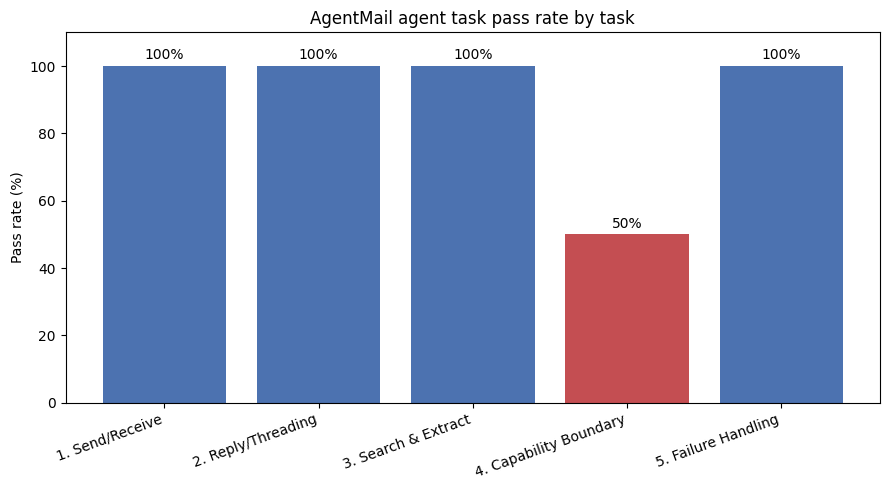

In [31]:
# bar chart of pass rate per task, task 4 should visibly stand out from the rest

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#4c72b0" if rate == 100 else "#c44e52" for rate in pass_rate_by_task["pass_rate_pct"]]

bars = ax.bar(pass_rate_by_task["task"], pass_rate_by_task["pass_rate_pct"], color=colors)

ax.set_ylim(0, 110)
ax.set_ylabel("Pass rate (%)")
ax.set_title("AgentMail agent task pass rate by task")
ax.set_xticklabels(pass_rate_by_task["task"], rotation=20, ha="right")

for bar, rate in zip(bars, pass_rate_by_task["pass_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 2, f"{int(rate)}%", ha="center")

plt.tight_layout()
plt.savefig("pass_rate_by_task.png", dpi=150)
plt.show()

In [32]:
# a short findings table, one row per task, pairing the pass rate with the actual takeaway

findings = [
    {"task": "1. Send/Receive", "pass_rate": "100%", "finding": "Basic send and receive works end to end and delivery was confirmed on the receiving inbox."},
    {"task": "2. Reply/Threading", "pass_rate": "100%", "finding": "Agent correctly chose reply over send and passed the exact message id through, consistent across 3 runs."},
    {"task": "3. Search & Extract", "pass_rate": "100%", "finding": "Agent found the one relevant message among 10 and extracted the correct value on its first real attempt."},
    {"task": "4. Capability Boundary", "pass_rate": "50%", "finding": "Agent invented a get_message function that was never defined. After being corrected, it recovered honestly but still slightly misdescribed its own available tools."},
    {"task": "5. Failure Handling", "pass_rate": "100%", "finding": "Agent correctly reported a real validation error from the API instead of assuming the send had succeeded."},
]

findings_df = pd.DataFrame(findings)
findings_df

,task,pass_rate,finding
0,1. Send/Receive,100%,Basic send and receive works end to end and de...
1,2. Reply/Threading,100%,Agent correctly chose reply over send and pass...
2,3. Search & Extract,100%,Agent found the one relevant message among 10 ...
3,4. Capability Boundary,50%,Agent invented a get_message function that was...
4,5. Failure Handling,100%,Agent correctly reported a real validation err...


## Summary

Out of five tasks tested, four passed cleanly and one surfaced a real problem worth flagging.

The agent handled threading, multi-step search across a cluttered inbox, and error reporting correctly, and did so with no example code shown, only tool descriptions and a plain instruction. The one weak point was task 4: when asked to do something outside its actual tool set, the agent invented a `get_message` function that was never defined anywhere in the schema. It recovered honestly once corrected, but even its correction slightly misstated which tools it actually had access to. That gap between what a model assumes an API probably supports and what it's actually been given is exactly the kind of failure that would be invisible without reading the raw trace, the final answer alone looked confident and reasonable.

This notebook tested core send, reply, search, and error handling behavior against a minimal tool schema. It did not test the MCP server directly, retrieval quality against the actual docs site, or behavior under sustained multi-turn use, those would be natural next steps if this were extended.